<a href="https://colab.research.google.com/github/random3770/exploratory-data-analysis/blob/main/experiment_6(18-8-26).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exploratory Data Analysis: Wine Quality Dataset
Following the structure of Module 3: Correlation and Types of Analysis.

In [147]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from scipy import stats

df = pd.read_csv('/content/WineQT.csv')

print("First 3 rows:")
display(df.head(3))
print("\nLast 3 rows:")
display(df.tail(3))

First 3 rows:


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2



Last 3 rows:


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
1140,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5,1594
1141,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6,1595
1142,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5,1597


In [148]:
print("Data Types:")
print(df.dtypes)
print("\nDescriptive Statistics:")
display(df.describe())
print("\nMissing values:")
print(df.isna().any())

Data Types:
fixed acidity           float64
volatile acidity        float64
citric acid             float64
residual sugar          float64
chlorides               float64
free sulfur dioxide     float64
total sulfur dioxide    float64
density                 float64
pH                      float64
sulphates               float64
alcohol                 float64
quality                   int64
Id                        int64
dtype: object

Descriptive Statistics:


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
count,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000
mean,8.311111,0.531339,0.268364,2.532152,0.086933,15.615486,45.914698,0.996730,3.311015,0.657708,10.442111,5.657043,804.969379
std,1.747595,0.179633,0.196686,1.355917,0.047267,10.250486,32.782130,0.001925,0.156664,0.170399,1.082196,0.805824,463.997116
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000,0.000000
25%,7.100000,0.392500,0.090000,1.900000,0.070000,7.000000,21.000000,0.995570,3.205000,0.550000,9.500000,5.000000,411.000000
50%,7.900000,0.520000,0.250000,2.200000,0.079000,13.000000,37.000000,0.996680,3.310000,0.620000,10.200000,6.000000,794.000000
75%,9.100000,0.640000,0.420000,2.600000,0.090000,21.000000,61.000000,0.997845,3.400000,0.730000,11.100000,6.000000,1209.500000
max,15.900000,1.580000,1.000000,15.500000,0.611000,68.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000,1597.000000



Missing values:
fixed acidity           False
volatile acidity        False
citric acid             False
residual sugar          False
chlorides               False
free sulfur dioxide     False
total sulfur dioxide    False
density                 False
pH                      False
sulphates               False
alcohol                 False
quality                 False
Id                      False
dtype: bool


## Univariate Analysis
Analyzing central tendency and dispersion for wine features.

Fixed Acidity - Mean: 8.311111111111112, Median: 7.9, Mode: 7.2


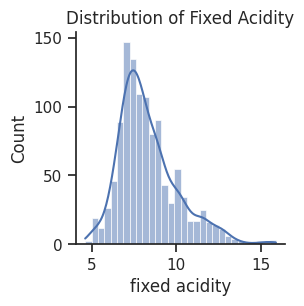

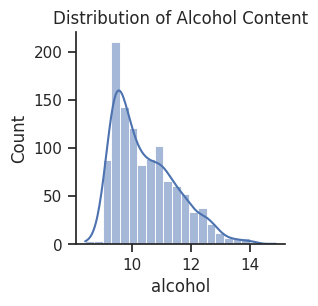

In [149]:
mean = df['fixed acidity'].mean()
median = df['fixed acidity'].median()
mode = df['fixed acidity'].mode()[0]
print(f"Fixed Acidity - Mean: {mean}, Median: {median}, Mode: {mode}")

sns.FacetGrid(df).map(sns.histplot, "fixed acidity", kde=True).add_legend()
plt.title('Distribution of Fixed Acidity')
plt.show()

sns.FacetGrid(df).map(sns.histplot, "alcohol", kde=True).add_legend()
plt.title('Distribution of Alcohol Content')
plt.show()

## Bivariate Analysis
Examining the relationship between two wine variables.

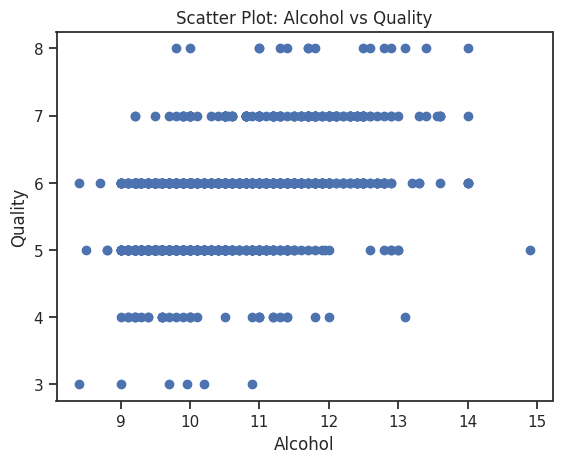

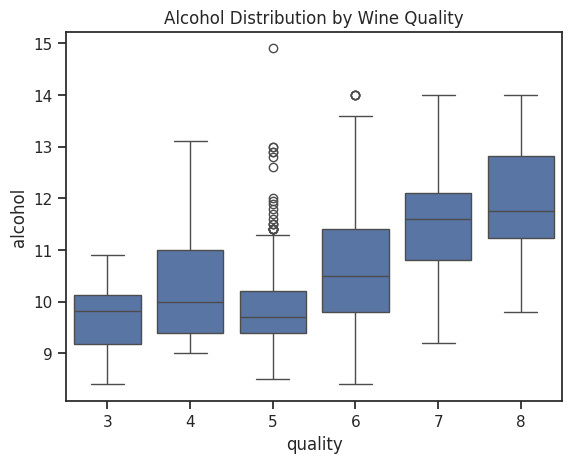

In [150]:
plt.scatter(df["alcohol"], df["quality"])
plt.title("Scatter Plot: Alcohol vs Quality")
plt.xlabel("Alcohol")
plt.ylabel("Quality")
plt.show()

sns.boxplot(x="quality", y="alcohol", data=df)
plt.title('Alcohol Distribution by Wine Quality')
plt.show()

## Multivariate Analysis
Analyzing relationships among multiple wine variables.

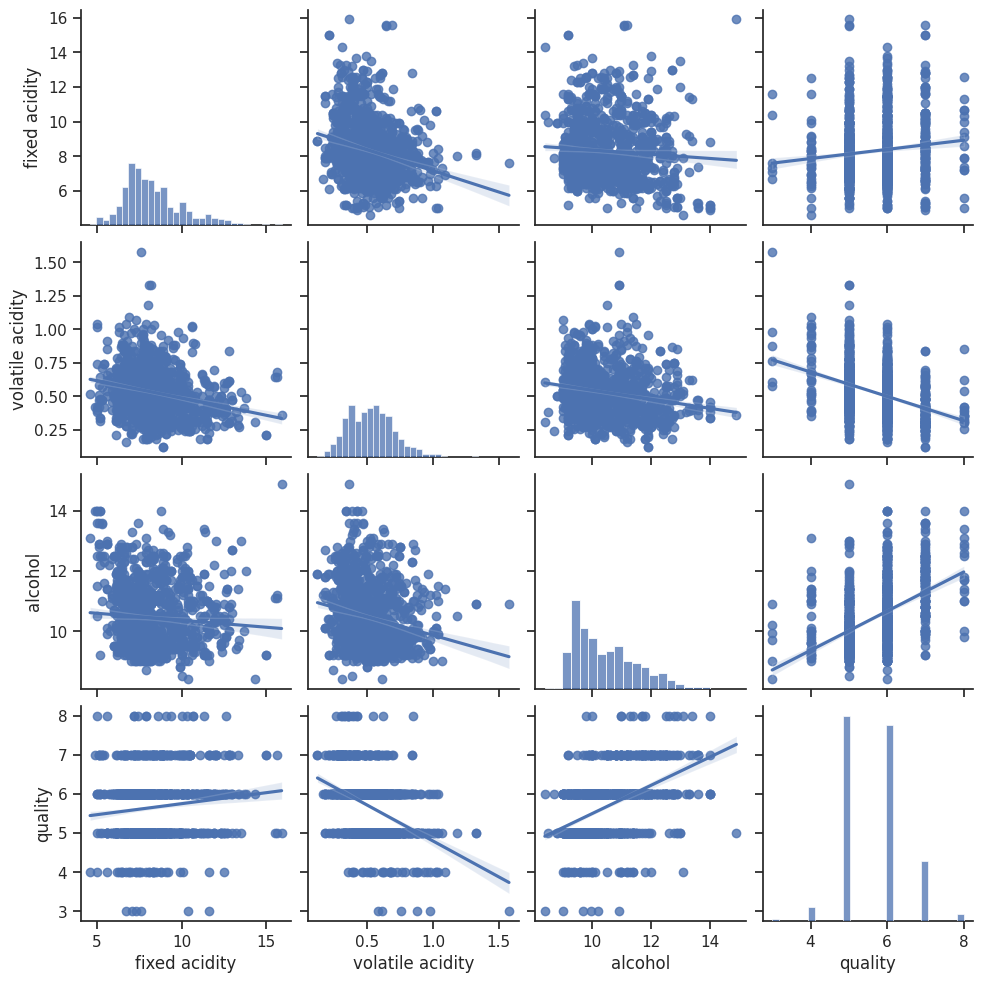

In [151]:
sns.pairplot(df, vars=['fixed acidity', 'volatile acidity', 'alcohol', 'quality'], kind="reg")
plt.show()

### Multivariate and Correlation Analysis
Following the example module to visualize specific feature interactions and the complete correlation matrix.

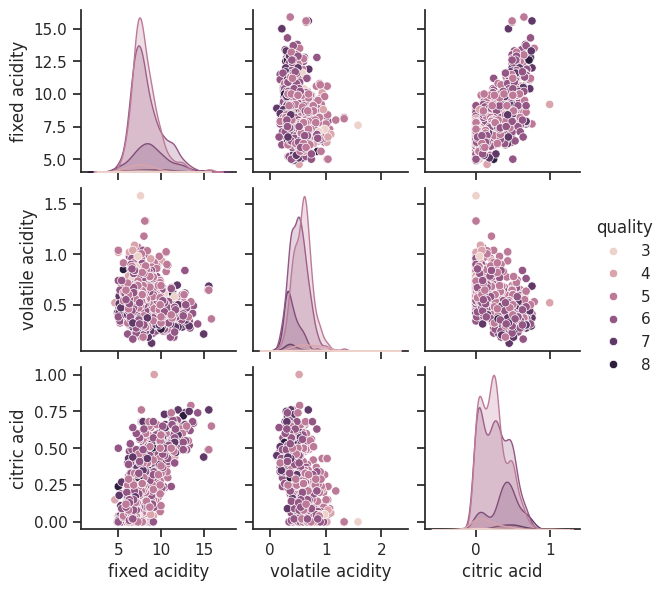

In [153]:
# 2. A pair plot by specifying colors, variables, and hue
sns.set(style="ticks", color_codes=True)
sns.pairplot(df, height=2, vars=['fixed acidity', 'volatile acidity', 'citric acid'], hue="quality")
plt.show()

In [154]:
# 3. Calculate the Pearson correlation coefficient for alcohol and quality
corr = stats.pearsonr(df["alcohol"], df["quality"])
print("p-value:\t", corr[1])
print("cor:\t\t", corr[0])

p-value:	 1.9246528151001656e-68
cor:		 0.4848662118085117


In [155]:
# 4. Find the correlation among all numerical records using the pearson method
correlation = df.corr(method='pearson', numeric_only=True)
display(correlation)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
fixed acidity,1.000000,-0.250728,0.673157,0.171831,0.107889,-0.164831,-0.110628,0.681501,-0.685163,0.174592,-0.075055,0.121970,-0.275826
volatile acidity,-0.250728,1.000000,-0.544187,-0.005751,0.056336,-0.001962,0.077748,0.016512,0.221492,-0.276079,-0.203909,-0.407394,-0.007892
citric acid,0.673157,-0.544187,1.000000,0.175815,0.245312,-0.057589,0.036871,0.375243,-0.546339,0.331232,0.106250,0.240821,-0.139011
residual sugar,0.171831,-0.005751,0.175815,1.000000,0.070863,0.165339,0.190790,0.380147,-0.116959,0.017475,0.058421,0.022002,-0.046344
chlorides,0.107889,0.056336,0.245312,0.070863,1.000000,0.015280,0.048163,0.208901,-0.277759,0.374784,-0.229917,-0.124085,-0.088099
free sulfur dioxide,-0.164831,-0.001962,-0.057589,0.165339,0.015280,1.000000,0.661093,-0.054150,0.072804,0.034445,-0.047095,-0.063260,0.095268
total sulfur dioxide,-0.110628,0.077748,0.036871,0.190790,0.048163,0.661093,1.000000,0.050175,-0.059126,0.026894,-0.188165,-0.183339,-0.107389
density,0.681501,0.016512,0.375243,0.380147,0.208901,-0.054150,0.050175,1.000000,-0.352775,0.143139,-0.494727,-0.175208,-0.363926
pH,-0.685163,0.221492,-0.546339,-0.116959,-0.277759,0.072804,-0.059126,-0.352775,1.000000,-0.185499,0.225322,-0.052453,0.132904
sulphates,0.174592,-0.276079,0.331232,0.017475,0.374784,0.034445,0.026894,0.143139,-0.185499,1.000000,0.094421,0.257710,-0.103954


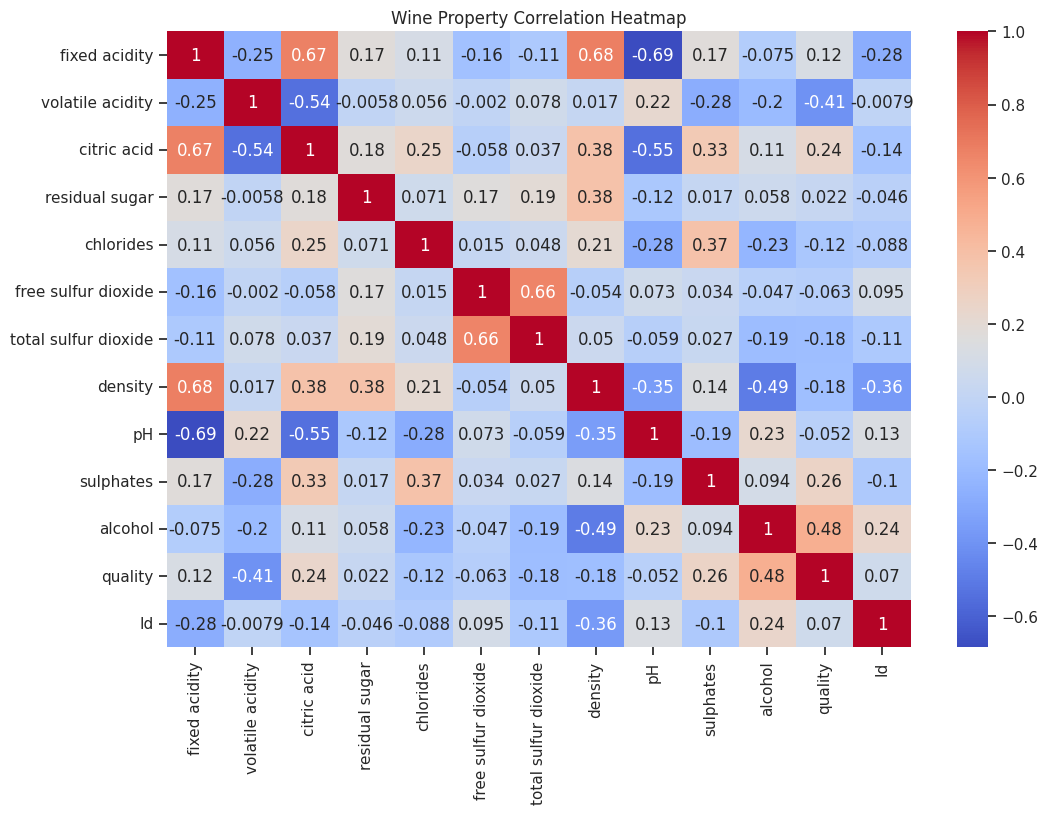

In [156]:
# 5. Visualize the correlation analysis using a heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(correlation, xticklabels=correlation.columns, yticklabels=correlation.columns, annot=True, cmap='coolwarm')
plt.title("Wine Property Correlation Heatmap")
plt.show()